# Практичне завдання 1: Лінійна регресія, оптимізація та статистичний аналіз

## Мета роботи

Зрозуміти архітектуру лінійної регресії, самостійно реалізувати алгоритми
градієнтної оптимізації, виконати відбір ознак, обчислити метрики якості
та перевірити статистичні припущення моделі.

**Датасет:** Ames Housing / House Prices - Advanced Regression Techniques  
**Цільова змінна:** `SalePrice`

> Усі алгоритми лінійної регресії, Gradient Descent та обчислення градієнтів
> для моделі реалізуються самостійно засобами NumPy.


## Зміст

1. Імпорт бібліотек
2. Завантаження та первинний аналіз даних
3. EDA та кореляційний аналіз
4. Вибір ознак
5. Train / Validation / Test split
6. Preprocessing без Data Leakage
7. Власна Linear Regression на NumPy
8. Batch Gradient Descent
9. SGD
10. Mini-batch Gradient Descent
11. Порівняння методів
12. R²
13. Аналіз залишків та статистичних припущень
14. Multicollinearity та VIF
15. Експеримент A: вплив масштабування
16. Підсумкові результати та автоматичні висновки


## 1. Імпорт бібліотек

`scikit-learn` використовується лише для допоміжних операцій:
розбиття вибірки, кодування категорій та масштабування.

**Linear Regression та Gradient Descent не використовують готову
реалізацію `LinearRegression` зі scikit-learn.**


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Завантаження датасету

Перед запуском переконайтеся, що файл має шлях:

```text
data/train.csv
```

і містить колонку `SalePrice`.


In [10]:
DATA_PATH = r"F:\4 курс\Машинне навчання\ML_Linear_Regression\data\train.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
print("Dataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

In [12]:
print("Descriptive statistics:")
display(df.describe(include="all").T)


Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1460.0,NaN,NaN,NaN,730.5,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,NaN,NaN,NaN,56.89726,42.300571,20.0,20.0,50.0,70.0,190.0
MSZoning,1460,5,RL,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1201.0,NaN,NaN,NaN,70.049958,24.284752,21.0,59.0,69.0,80.0,313.0
LotArea,1460.0,NaN,NaN,NaN,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.5,215245.0
...,...,...,...,...,...,...,...,...,...,...,...
MoSold,1460.0,NaN,NaN,NaN,6.321918,2.703626,1.0,5.0,6.0,8.0,12.0
YrSold,1460.0,NaN,NaN,NaN,2007.815753,1.328095,2006.0,2007.0,2008.0,2009.0,2010.0
SaleType,1460,9,WD,1267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SaleCondition,1460,6,Normal,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Пропущені значення

На цьому етапі ми лише досліджуємо пропуски. Їх обробка буде виконана
після Train / Validation / Test split, щоб не допустити Data Leakage.


In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Columns with missing values: {len(missing)}")
display(missing.to_frame("Missing values"))

missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
display(missing_percent[missing_percent > 0].to_frame("Missing %"))


Columns with missing values: 19


,Missing values
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


,Missing %
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageQual,5.547945
GarageFinish,5.547945
GarageType,5.547945


## 4. Аналіз цільової змінної `SalePrice`


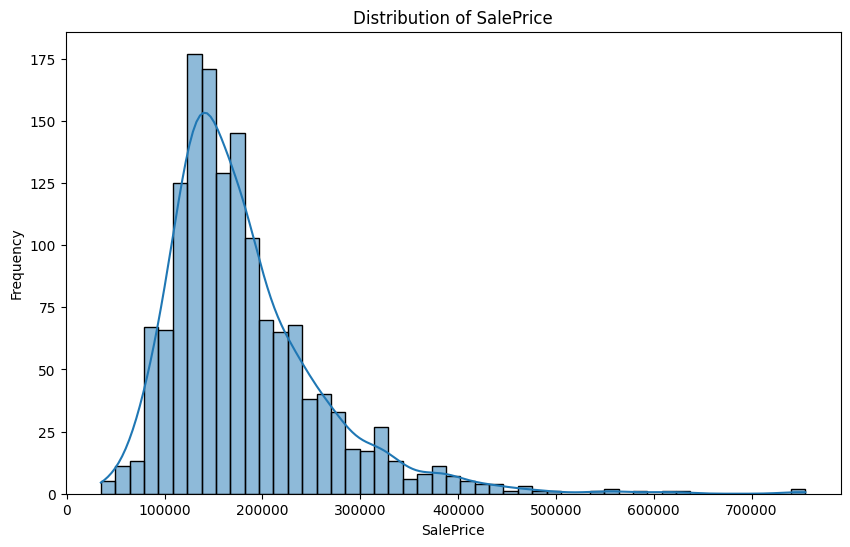

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df["SalePrice"], kde=True, ax=ax)
ax.set_title("Distribution of SalePrice")
ax.set_xlabel("SalePrice")
ax.set_ylabel("Frequency")
plt.show()


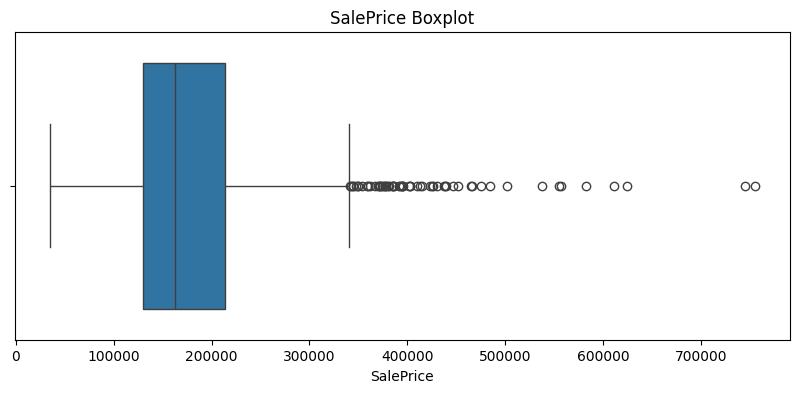

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=df["SalePrice"], ax=ax)
ax.set_title("SalePrice Boxplot")
plt.show()


### Попередній висновок EDA

`SalePrice` є числовою цільовою змінною задачі регресії. За графіками
можна оцінити форму розподілу, асиметрію та наявність потенційних
викидів.

**Автоматичні числові характеристики:**


In [16]:
saleprice_skew = df["SalePrice"].skew()
saleprice_mean = df["SalePrice"].mean()
saleprice_median = df["SalePrice"].median()
saleprice_min = df["SalePrice"].min()
saleprice_max = df["SalePrice"].max()

print(f"Mean:   {saleprice_mean:,.2f}")
print(f"Median: {saleprice_median:,.2f}")
print(f"Min:    {saleprice_min:,.2f}")
print(f"Max:    {saleprice_max:,.2f}")
print(f"Skewness: {saleprice_skew:.4f}")

if abs(saleprice_skew) < 0.5:
    interpretation = "Розподіл має відносно невелику асиметрію."
elif saleprice_skew > 0:
    interpretation = "Розподіл має праву асиметрію."
else:
    interpretation = "Розподіл має ліву асиметрію."

print("Автоматичний висновок:", interpretation)


Mean:   180,921.20
Median: 163,000.00
Min:    34,900.00
Max:    755,000.00
Skewness: 1.8829
Автоматичний висновок: Розподіл має праву асиметрію.


## 5. Вибір ознак

Для моделі використаємо такі ознаки:

### Числові
- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `YearBuilt`
- `TotalBsmtSF`
- `LotArea`

### Категоріальні
- `Neighborhood`
- `KitchenQual`
- `BldgType`
- `HouseStyle`

`One-Hot Encoding` використовується для категоріальних ознак, оскільки
ці категорії не мають природного числового порядку.


In [17]:
selected_numeric = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "YearBuilt",
    "TotalBsmtSF",
    "LotArea"
]

selected_categorical = [
    "Neighborhood",
    "KitchenQual",
    "BldgType",
    "HouseStyle"
]

selected_features = selected_numeric + selected_categorical

missing_selected = [
    col for col in selected_features + ["SalePrice"]
    if col not in df.columns
]

if missing_selected:
    raise ValueError(f"Missing required columns: {missing_selected}")

print("Selected numeric features:", selected_numeric)
print("Selected categorical features:", selected_categorical)


Selected numeric features: ['OverallQual', 'GrLivArea', 'GarageCars', 'YearBuilt', 'TotalBsmtSF', 'LotArea']
Selected categorical features: ['Neighborhood', 'KitchenQual', 'BldgType', 'HouseStyle']


### Обґрунтування вибору ознак

`OverallQual` характеризує загальну якість будинку та очікувано має
сильний зв'язок із ціною.

`GrLivArea` описує площу житлового простору. `GarageCars` характеризує
місткість гаража. `YearBuilt` описує рік побудови. `TotalBsmtSF`
характеризує площу підвалу, а `LotArea` — площу земельної ділянки.

Категоріальні ознаки `Neighborhood`, `KitchenQual`, `BldgType` та
`HouseStyle` додають інформацію про розташування, якість кухні та тип
будинку.

Остаточна доцільність вибору перевіряється за допомогою кореляційного
аналізу та аналізу мультиколінеарності.


## 6. Кореляційний аналіз

Спочатку аналізуємо числові ознаки та їхній зв'язок із `SalePrice`.
Також перевіряємо сильні кореляції між самими ознаками.


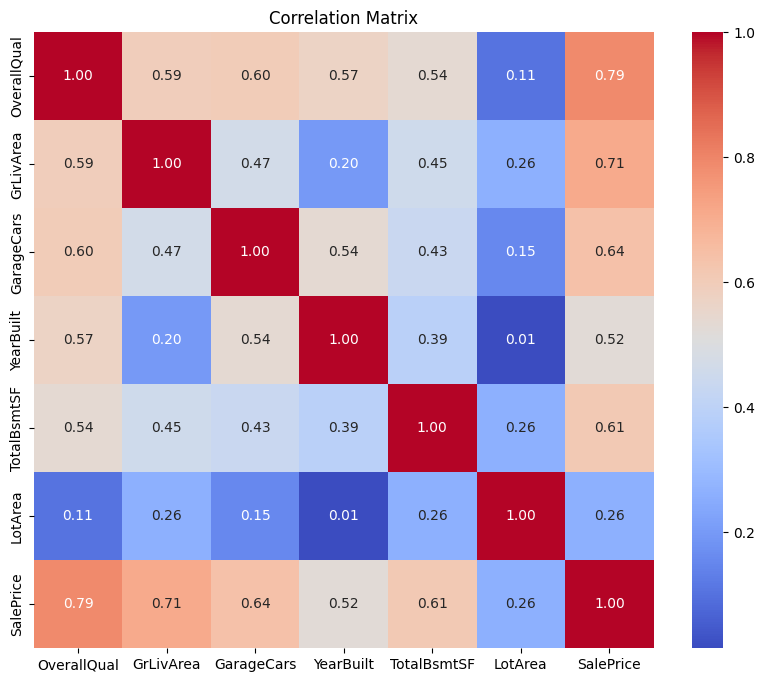

In [18]:
numeric_for_corr = selected_numeric + ["SalePrice"]

corr = df[numeric_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [19]:
saleprice_corr = (
    df.select_dtypes(include=np.number)
      .corr()["SalePrice"]
      .sort_values(ascending=False)
)

display(saleprice_corr.to_frame("Correlation with SalePrice"))


,Correlation with SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [20]:
print("Absolute correlations with SalePrice:")
display(
    saleprice_corr.drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
    .to_frame("|Correlation|")
)


Absolute correlations with SalePrice:


,|Correlation|
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


### Автоматичний висновок щодо кореляцій


In [21]:
corr_without_target = corr.drop(index="SalePrice", columns="SalePrice")
strong_pairs = []

for i in range(len(corr_without_target.columns)):
    for j in range(i + 1, len(corr_without_target.columns)):
        value = corr_without_target.iloc[i, j]
        if abs(value) >= 0.7:
            strong_pairs.append((
                corr_without_target.columns[i],
                corr_without_target.columns[j],
                value
            ))

if strong_pairs:
    print("Виявлено потенційно сильні кореляції між ознаками:")
    for a, b, value in strong_pairs:
        print(f"  {a} <-> {b}: r = {value:.3f}")
    print("Це може свідчити про потенційну мультиколінеарність.")
else:
    print("Кореляцій >= |0.70| між вибраними числовими ознаками не виявлено.")


Кореляцій >= |0.70| між вибраними числовими ознаками не виявлено.


## 7. Train / Validation / Test split

**Критично важливо:** спочатку розділяємо дані, а лише після цього
навчаємо preprocessing.

Використаємо:
- Train — 60%
- Validation — 20%
- Test — 20%

Validation використовується для вибору параметрів та порівняння моделей.
Test використовується лише для фінальної оцінки.


In [22]:
X = df[selected_features].copy()
y = df["SalePrice"].copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (876, 10)
Validation: (292, 10)
Test: (292, 10)


## 8. Data Leakage

Data Leakage виникає, коли під час навчання або preprocessing модель
отримує інформацію, яка повинна бути невідомою на момент навчання.

Наприклад, якщо `StandardScaler` навчити на всьому датасеті, середнє
та стандартне відхилення міститимуть інформацію з Validation і Test.

Правильний порядок:

1. Split.
2. `fit` preprocessing тільки на Train.
3. `transform` Train, Validation та Test.
4. Навчання моделі на Train.
5. Вибір параметрів за Validation.
6. Фінальна оцінка на Test.


## 9. Preprocessing

### 9.1 Заповнення пропусків

Параметри імпутації обчислюються **тільки на Train**.

Для числових ознак використовуємо медіану, для категоріальних —
найчастішу категорію.


In [23]:
numeric_medians = X_train[selected_numeric].median()

X_train_num = X_train[selected_numeric].fillna(numeric_medians)
X_val_num = X_val[selected_numeric].fillna(numeric_medians)
X_test_num = X_test[selected_numeric].fillna(numeric_medians)

categorical_modes = X_train[selected_categorical].mode().iloc[0]

X_train_cat = X_train[selected_categorical].fillna(categorical_modes)
X_val_cat = X_val[selected_categorical].fillna(categorical_modes)
X_test_cat = X_test[selected_categorical].fillna(categorical_modes)

print("Remaining missing values in Train:",
      X_train_num.isnull().sum().sum() + X_train_cat.isnull().sum().sum())
print("Remaining missing values in Validation:",
      X_val_num.isnull().sum().sum() + X_val_cat.isnull().sum().sum())
print("Remaining missing values in Test:",
      X_test_num.isnull().sum().sum() + X_test_cat.isnull().sum().sum())


Remaining missing values in Train: 0
Remaining missing values in Validation: 0
Remaining missing values in Test: 0


### 9.2 One-Hot Encoding

Використовуємо `OneHotEncoder(handle_unknown="ignore")`.

`handle_unknown="ignore"` дозволяє коректно обробити категорію, яка
може зустрітися у Validation/Test, але не зустрічалася у Train.
Encoder не перевчиться на Validation/Test.


In [24]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat_encoded = encoder.fit_transform(X_train_cat)
X_val_cat_encoded = encoder.transform(X_val_cat)
X_test_cat_encoded = encoder.transform(X_test_cat)

print("Encoded categorical shape:", X_train_cat_encoded.shape)


Encoded categorical shape: (876, 41)


### 9.3 Standardization

Параметри стандартизації обчислюються тільки на Train.


In [25]:
scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_val_num_scaled = scaler.transform(X_val_num)
X_test_num_scaled = scaler.transform(X_test_num)

print("Train means after scaling:")
print(np.mean(X_train_num_scaled, axis=0))
print("\nTrain std after scaling:")
print(np.std(X_train_num_scaled, axis=0))


Train means after scaling:
[ 1.50057541e-16  6.48897476e-17  2.02780461e-18  1.39918518e-15
 -5.47507245e-17  8.11121844e-18]

Train std after scaling:
[1. 1. 1. 1. 1. 1.]


In [26]:
X_train_processed = np.hstack([
    X_train_num_scaled,
    X_train_cat_encoded
])

X_val_processed = np.hstack([
    X_val_num_scaled,
    X_val_cat_encoded
])

X_test_processed = np.hstack([
    X_test_num_scaled,
    X_test_cat_encoded
])

y_train_np = y_train.to_numpy(dtype=float)
y_val_np = y_val.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=float)

print("Final Train matrix:", X_train_processed.shape)
print("Final Validation matrix:", X_val_processed.shape)
print("Final Test matrix:", X_test_processed.shape)


Final Train matrix: (876, 47)
Final Validation matrix: (292, 47)
Final Test matrix: (292, 47)


## 10. Власна Linear Regression на NumPy

Модель:

$$
\hat{y} = Xw + b
$$

Mean Squared Error:

$$
J(w,b)=\frac{1}{m}\sum_{i=1}^{m}(\hat y_i-y_i)^2
$$

Градієнти:

$$
\frac{\partial J}{\partial w}
=
\frac{2}{m}X^T(\hat y-y)
$$

$$
\frac{\partial J}{\partial b}
=
\frac{2}{m}\sum(\hat y-y)
$$

Оновлення:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

Обчислення прогнозу, Cost та градієнтів виконуються векторизовано
засобами NumPy. Normal Equation для основної моделі не використовується.


In [27]:
class LinearRegressionNumpy:

    def __init__(self):
        self.w = None
        self.b = 0.0

    def predict(self, X):
        return X @ self.w + self.b

    def mse(self, X, y):
        predictions = self.predict(X)
        errors = predictions - y
        return np.mean(errors ** 2)

    def gradients(self, X, y):
        m = X.shape[0]

        predictions = self.predict(X)
        errors = predictions - y

        dw = (2.0 / m) * (X.T @ errors)
        db = (2.0 / m) * np.sum(errors)

        return dw, db


## 11. Batch Gradient Descent

Batch GD використовує весь Train для обчислення одного градієнта.
Це зазвичай забезпечує найбільш стабільну траєкторію оптимізації.


In [28]:
def batch_gradient_descent(
    X,
    y,
    learning_rate=0.01,
    epochs=1000,
    tolerance=1e-8
):
    model = LinearRegressionNumpy()

    n_features = X.shape[1]
    model.w = np.zeros(n_features, dtype=float)
    model.b = 0.0

    history = []

    for epoch in range(epochs):
        dw, db = model.gradients(X, y)

        model.w -= learning_rate * dw
        model.b -= learning_rate * db

        cost = model.mse(X, y)
        history.append(cost)

        if epoch > 0 and abs(history[-1] - history[-2]) < tolerance:
            break

    return model, history


## 12. Stochastic Gradient Descent (SGD)

SGD оновлює параметри після кожного окремого прикладу.
Через це градієнт має більше шуму, а Cost може сильніше коливатися.


In [29]:
def stochastic_gradient_descent(
    X,
    y,
    learning_rate=0.0001,
    epochs=100,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    model = LinearRegressionNumpy()

    n_samples, n_features = X.shape

    model.w = np.zeros(n_features, dtype=float)
    model.b = 0.0

    history = []

    for epoch in range(epochs):
        indices = rng.permutation(n_samples)

        for idx in indices:
            xi = X[idx:idx + 1]
            yi = y[idx:idx + 1]

            dw, db = model.gradients(xi, yi)

            model.w -= learning_rate * dw
            model.b -= learning_rate * db

        cost = model.mse(X, y)
        history.append(cost)

    return model, history


## 13. Mini-batch Gradient Descent

Mini-batch GD використовує невеликі групи прикладів. У роботі
використаємо `batch_size = 32`.


In [30]:
def mini_batch_gradient_descent(
    X,
    y,
    learning_rate=0.01,
    epochs=100,
    batch_size=32,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    model = LinearRegressionNumpy()

    n_samples, n_features = X.shape

    model.w = np.zeros(n_features, dtype=float)
    model.b = 0.0

    history = []

    for epoch in range(epochs):
        indices = rng.permutation(n_samples)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            dw, db = model.gradients(X_batch, y_batch)

            model.w -= learning_rate * dw
            model.b -= learning_rate * db

        cost = model.mse(X, y)
        history.append(cost)

    return model, history


## 14. Навчання трьох моделей

Параметри Learning Rate підібрані як стартові значення для
стандартизованих ознак. Пізніше їх можна змінити на основі графіків
та експерименту з Learning Rate.


In [31]:
batch_model, batch_history = batch_gradient_descent(
    X_train_processed,
    y_train_np,
    learning_rate=0.01,
    epochs=1000
)

sgd_model, sgd_history = stochastic_gradient_descent(
    X_train_processed,
    y_train_np,
    learning_rate=0.0001,
    epochs=100
)

mini_model, mini_history = mini_batch_gradient_descent(
    X_train_processed,
    y_train_np,
    learning_rate=0.01,
    epochs=100,
    batch_size=32
)

print("Batch GD epochs:", len(batch_history))
print("SGD epochs:", len(sgd_history))
print("Mini-batch GD epochs:", len(mini_history))


Batch GD epochs: 1000
SGD epochs: 100
Mini-batch GD epochs: 100


## 15. Порівняння Cost Function

Відповідно до вимог роботи будуємо графік залежності Cost Function
від Epochs для всіх трьох методів на одному рисунку.


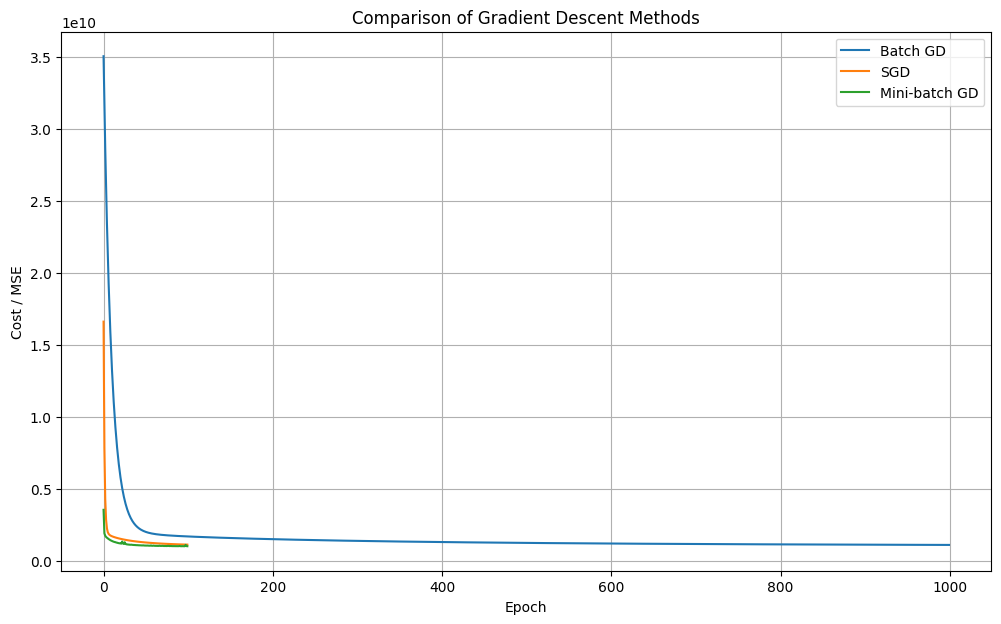

In [32]:
plt.figure(figsize=(12, 7))

plt.plot(batch_history, label="Batch GD")
plt.plot(sgd_history, label="SGD")
plt.plot(mini_history, label="Mini-batch GD")

plt.xlabel("Epoch")
plt.ylabel("Cost / MSE")
plt.title("Comparison of Gradient Descent Methods")
plt.legend()
plt.grid(True)
plt.show()


### Автоматичний аналіз збіжності


In [33]:
history_dict = {
    "Batch GD": batch_history,
    "SGD": sgd_history,
    "Mini-batch GD": mini_history
}

for name, history in history_dict.items():
    print(
        f"{name}: initial={history[0]:.4f}, "
        f"final={history[-1]:.4f}, "
        f"epochs={len(history)}"
    )

final_costs = {name: history[-1] for name, history in history_dict.items()}
best_cost_method = min(final_costs, key=final_costs.get)

print(f"\nНайменший фінальний Train Cost: {best_cost_method}")
print("SGD зазвичай має найбільші коливання через використання одного прикладу.")
print("Batch GD зазвичай є найстабільнішим, а Mini-batch GD є компромісом.")


Batch GD: initial=35026237639.9945, final=1109854146.9849, epochs=1000
SGD: initial=16606098373.3017, final=1130656525.5642, epochs=100
Mini-batch GD: initial=3545078145.0691, final=1020733972.3781, epochs=100

Найменший фінальний Train Cost: Mini-batch GD
SGD зазвичай має найбільші коливання через використання одного прикладу.
Batch GD зазвичай є найстабільнішим, а Mini-batch GD є компромісом.


## 16. R²

Коефіцієнт детермінації:

$$
R^2 =
1 -
\frac{\sum (y_i-\hat y_i)^2}
{\sum (y_i-\bar y)^2}
$$

R² показує, наскільки модель пояснює варіацію цільової змінної
порівняно з прогнозуванням її середнього значення.

R² може бути від'ємним, якщо модель працює гірше за базовий прогноз
середнім значенням.


In [34]:
def r2_score_numpy(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot == 0:
        return np.nan

    return 1.0 - ss_res / ss_tot


In [35]:
models = {
    "Batch GD": batch_model,
    "SGD": sgd_model,
    "Mini-batch GD": mini_model
}

results = []

for name, model in models.items():
    train_pred = model.predict(X_train_processed)
    val_pred = model.predict(X_val_processed)
    test_pred = model.predict(X_test_processed)

    results.append({
        "Method": name,
        "Train R2": r2_score_numpy(y_train_np, train_pred),
        "Validation R2": r2_score_numpy(y_val_np, val_pred),
        "Test R2": r2_score_numpy(y_test_np, test_pred)
    })

results_df = pd.DataFrame(results)
display(results_df)


,Method,Train R2,Validation R2,Test R2
0,Batch GD,0.813671,0.823030,0.826770
1,SGD,0.810179,0.820316,0.824110
2,Mini-batch GD,0.828633,0.832495,0.838379


## 17. Аналіз Train vs Validation vs Test

Високий Train R² при суттєво нижчому Test R² може свідчити про
overfitting.

Якщо Train, Validation і Test R² близькі, модель має більш стабільне
узагальнення.

Для фінального висновку використовуємо фактичні значення з таблиці.


In [38]:
best_test_row = results_df.loc[results_df["Test R2"].idxmax()]

print(f"Найкращий Test R²: {best_test_row['Method']}")
print(f"Test R² = {best_test_row['Test R2']:.4f}")

train_r2_best = best_test_row["Train R2"]
val_r2_best = best_test_row["Validation R2"]
test_r2_best = best_test_row["Test R2"]

generalization_gap = train_r2_best - test_r2_best

print(f"Train-Test R² gap = {generalization_gap:.4f}")

if generalization_gap > 0.15:
    print("Автоматичний висновок: є помітний розрив Train/Test, можливий overfitting.")
elif generalization_gap > 0.05:
    print("Автоматичний висновок: є помірний розрив Train/Test.")
else:
    print("Автоматичний висновок: Train та Test R² відносно близькі.")


Найкращий Test R²: Mini-batch GD
Test R² = 0.8384
Train-Test R² gap = -0.0097
Автоматичний висновок: Train та Test R² відносно близькі.


# 18. Статистичні припущення лінійної регресії

Перевіримо:

1. Лінійність — Residuals vs Fitted.
2. Нормальність залишків — Q-Q plot та Shapiro-Wilk.
3. Гомоскедастичність — Scale-Location plot.
4. Відсутність сильної мультиколінеарності — correlation matrix та VIF.

Залишок визначається як:

$$
\epsilon = y - \hat y
$$


In [39]:
# Для статистичного аналізу використовуємо найкращу модель за Test R²
best_method = best_test_row["Method"]
best_model = models[best_method]

best_test_predictions = best_model.predict(X_test_processed)
residuals = y_test_np - best_test_predictions

print("Model used for residual analysis:", best_method)
print("Residual mean:", np.mean(residuals))
print("Residual std:", np.std(residuals))


Model used for residual analysis: Mini-batch GD
Residual mean: 2220.046758016033
Residual std: 35139.07052205306


## 18.1 Linearity — Residuals vs Fitted


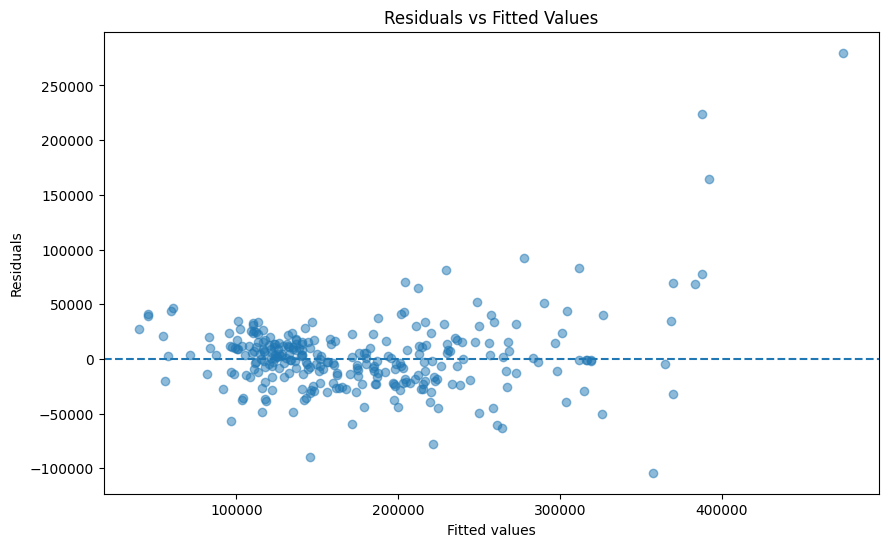

In [40]:
plt.figure(figsize=(10, 6))

plt.scatter(
    best_test_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


### Висновок щодо лінійності

Припущення лінійності виконується приблизно, але з застереженнями — для дешевших будинків модель точніша, для найдорожчих є систематичне недооцінення
(residuals стають більшими й переважно додатними).


## 18.2 Normality — Q-Q plot


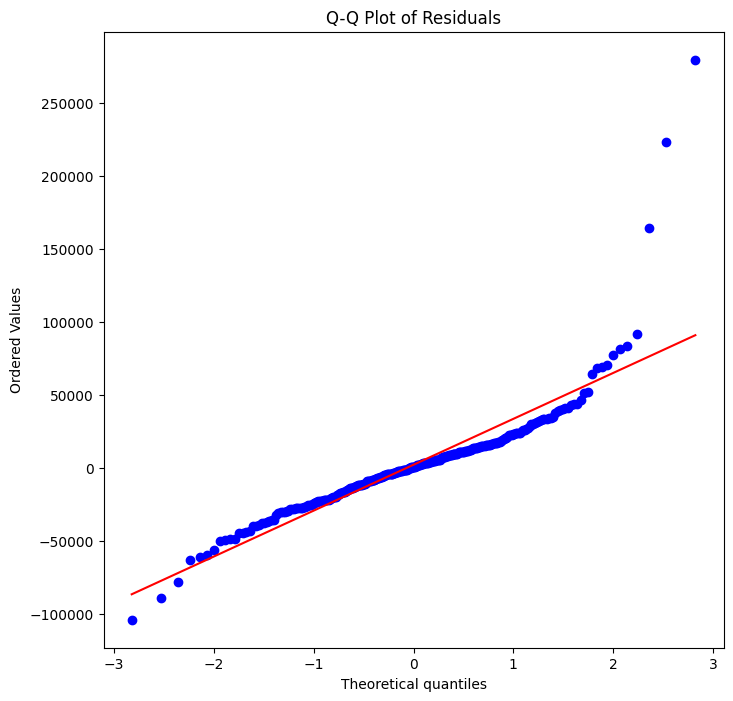

In [41]:
plt.figure(figsize=(8, 8))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals")
plt.show()


In [42]:
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"Shapiro-Wilk statistic: {shapiro_stat:.6f}")
print(f"p-value: {shapiro_p:.6g}")

if shapiro_p < 0.05:
    print(
        "Автоматичний висновок: p-value < 0.05, "
        "тому нульову гіпотезу про нормальність відхиляємо."
    )
else:
    print(
        "Автоматичний висновок: p-value >= 0.05, "
        "немає достатніх підстав відхиляти нормальність."
    )

print(
    "Q-Q plot потрібно також оцінити візуально, "
    "оскільки Shapiro-Wilk чутливий до розміру вибірки."
)


Shapiro-Wilk statistic: 0.798306
p-value: 9.79774e-19
Автоматичний висновок: p-value < 0.05, тому нульову гіпотезу про нормальність відхиляємо.
Q-Q plot потрібно також оцінити візуально, оскільки Shapiro-Wilk чутливий до розміру вибірки.


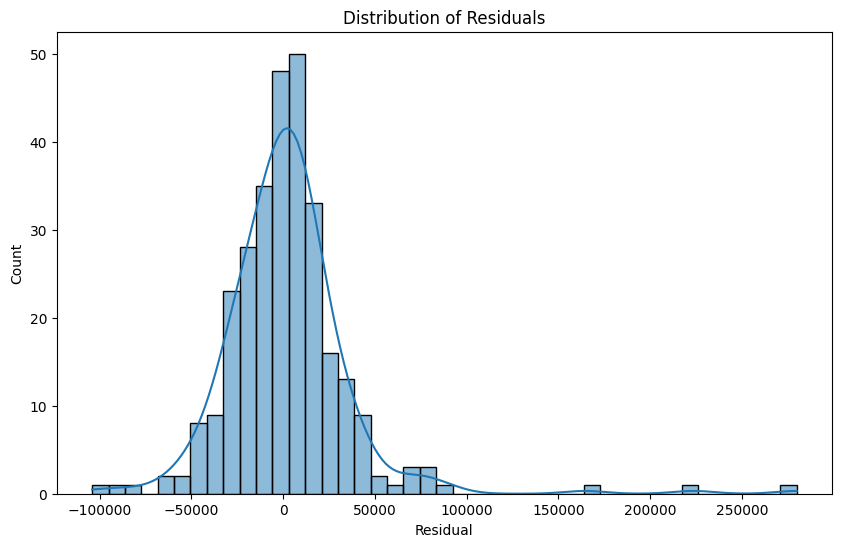

In [43]:
plt.figure(figsize=(10, 6))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()


## 18.3 Homoscedasticity — Scale-Location

Гомоскедастичність означає приблизно однакову дисперсію помилок
для різних рівнів fitted values.


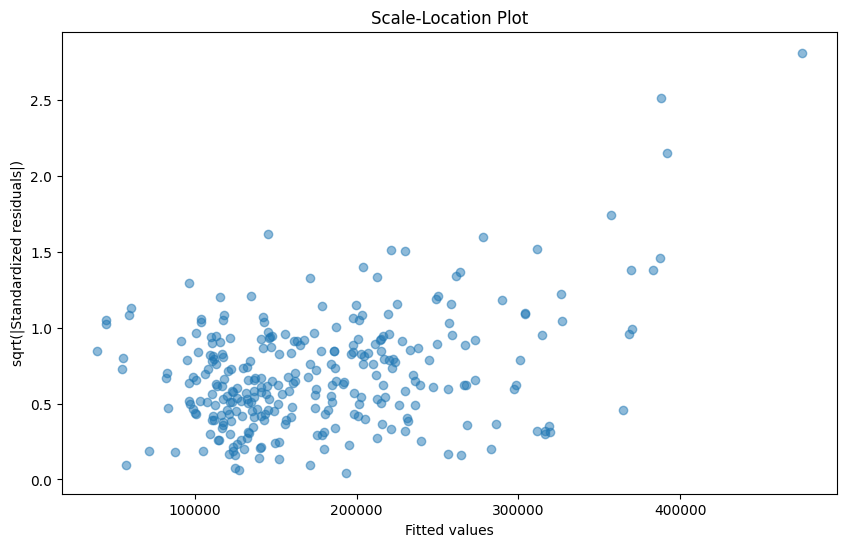

In [44]:
standardized_residuals = (
    residuals - np.mean(residuals)
) / np.std(residuals)

sqrt_abs_residuals = np.sqrt(
    np.abs(standardized_residuals)
)

plt.figure(figsize=(10, 6))

plt.scatter(
    best_test_predictions,
    sqrt_abs_residuals,
    alpha=0.5
)

plt.xlabel("Fitted values")
plt.ylabel("sqrt(|Standardized residuals|)")
plt.title("Scale-Location Plot")
plt.show()


### Висновок щодо гомоскедастичності

На Scale-Location plot розкид точок явно зростає з fitted values (від ~0.2 ліворуч до >2.5 для кількох дорогих будинків праворуч) — це ознака гетероскедастичності: дисперсія помилок не стала, а зростає для дорожчих об'єктів.


# 19. Multicollinearity

Мультиколінеарність виникає, коли предиктори мають сильний лінійний
зв'язок між собою. Вона може зробити окремі коефіцієнти нестабільними
та ускладнити їх інтерпретацію.


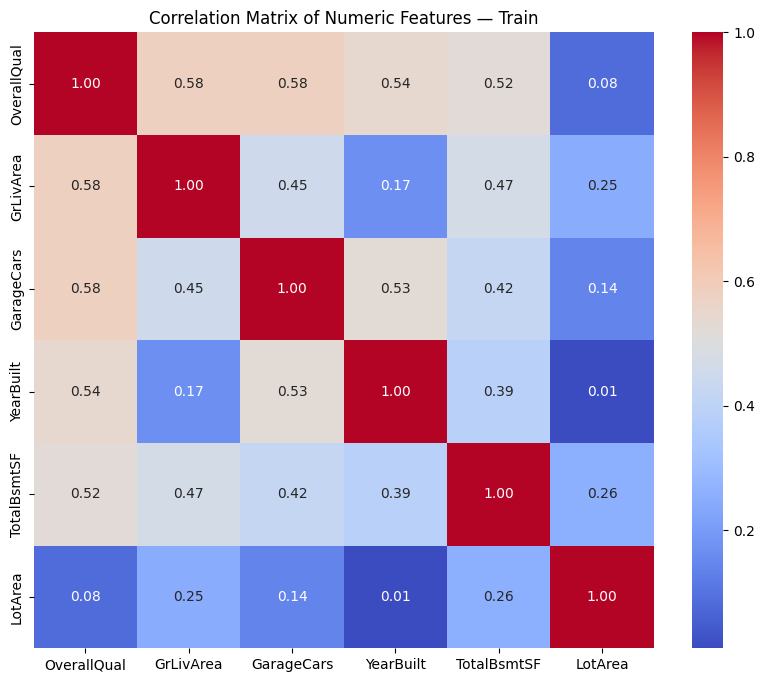

In [45]:
numeric_train_df = X_train[selected_numeric].copy()

plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_train_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of Numeric Features — Train")
plt.show()


## 19.1 VIF

Використовуємо:

$$
VIF_i = \frac{1}{1-R_i^2}
$$

де $R_i^2$ — R² регресії i-ої ознаки на всі інші ознаки.

Для VIF використовуємо числові ознаки Train. Це також унеможливлює
використання Test для відбору ознак.


In [46]:
def calculate_vif(X):
    X = np.asarray(X, dtype=float)

    n_features = X.shape[1]
    vif_values = []

    for i in range(n_features):
        y_feature = X[:, i]

        other_indices = [
            j for j in range(n_features)
            if j != i
        ]

        X_other = X[:, other_indices]

        X_other_with_bias = np.column_stack([
            np.ones(X_other.shape[0]),
            X_other
        ])

        coefficients = np.linalg.lstsq(
            X_other_with_bias,
            y_feature,
            rcond=None
        )[0]

        predictions = X_other_with_bias @ coefficients

        r2 = r2_score_numpy(
            y_feature,
            predictions
        )

        if r2 >= 0.999999:
            vif = np.inf
        else:
            vif = 1.0 / (1.0 - r2)

        vif_values.append(vif)

    return np.array(vif_values)


vif_values = calculate_vif(X_train_num_scaled)

vif_table = pd.DataFrame({
    "Feature": selected_numeric,
    "VIF": vif_values
})

display(vif_table)


,Feature,VIF
0,OverallQual,2.400034
1,GrLivArea,1.874362
2,GarageCars,1.805962
3,YearBuilt,1.761991
4,TotalBsmtSF,1.598626
5,LotArea,1.128245


In [47]:
max_vif_row = vif_table.loc[vif_table["VIF"].idxmax()]

print(
    f"Найбільший VIF: {max_vif_row['Feature']} = "
    f"{max_vif_row['VIF']:.3f}"
)

if max_vif_row["VIF"] > 10:
    print("Автоматичний висновок: виявлено сильну мультиколінеарність.")
elif max_vif_row["VIF"] > 5:
    print("Автоматичний висновок: можлива суттєва мультиколінеарність.")
else:
    print("Автоматичний висновок: критичної мультиколінеарності за VIF не виявлено.")


Найбільший VIF: OverallQual = 2.400
Автоматичний висновок: критичної мультиколінеарності за VIF не виявлено.


## 19.2 Вплив мультиколінеарності на коефіцієнти

Мультиколінеарність не обов'язково означає погане прогнозування.
Основна проблема полягає у стабільності та інтерпретації окремих
коефіцієнтів.

Якщо ознаки сильно корельовані, модель може мати труднощі з
визначенням, яка саме ознака відповідає за певну частину ефекту.
Через це ваги можуть бути нестабільними.

**Висновок:**
мультиколінеарність не виявлено, це не повинно суттєво впливати на стабільність коефіцієнтів.

In [48]:
numeric_weight_count = len(selected_numeric)

coefficient_table = pd.DataFrame({
    "Feature": selected_numeric,
    "Weight": best_model.w[:numeric_weight_count]
})

display(coefficient_table)


,Feature,Weight
0,OverallQual,20096.274582
1,GrLivArea,27240.318691
2,GarageCars,10914.473981
3,YearBuilt,13539.957912
4,TotalBsmtSF,-1583.577778
5,LotArea,5590.692501


# 20. Експеримент A — вплив масштабування

Порівнюємо Mini-batch GD:
1. на даних без стандартизації;
2. на стандартизованих даних.

Мета — порівняти швидкість збіжності та вплив масштабу ознак
на вибір Learning Rate.

Без стандартизації різні ознаки можуть мати дуже різні масштаби.
Через це поверхня функції втрат може бути витягнутою, а Gradient
Descent може здійснювати великі коливання вздовж одного напрямку
та дуже повільно рухатися вздовж іншого.

Після стандартизації масштаби ознак стають близькими, тому поверхня
функції втрат стає більш зручною для руху Gradient Descent.


## 20.1 Дані без стандартизації

Категоріальні ознаки залишаються One-Hot encoded, але числові ознаки
не проходять StandardScaler.


In [49]:
X_train_num_raw = X_train[selected_numeric].fillna(
    numeric_medians
)

X_val_num_raw = X_val[selected_numeric].fillna(
    numeric_medians
)

X_test_num_raw = X_test[selected_numeric].fillna(
    numeric_medians
)

X_train_raw = np.hstack([
    X_train_num_raw.to_numpy(dtype=float),
    X_train_cat_encoded
])

X_val_raw = np.hstack([
    X_val_num_raw.to_numpy(dtype=float),
    X_val_cat_encoded
])

X_test_raw = np.hstack([
    X_test_num_raw.to_numpy(dtype=float),
    X_test_cat_encoded
])

print("Unscaled Train matrix:", X_train_raw.shape)


Unscaled Train matrix: (876, 47)


### Підбір Learning Rate для unscaled даних

Через різні масштаби ознак Learning Rate має бути значно меншим.
Початкове значення нижче є навмисно малим.


In [50]:
unscaled_model, unscaled_history = mini_batch_gradient_descent(
    X_train_raw,
    y_train_np,
    learning_rate=1e-9,
    epochs=100,
    batch_size=32
)

print("Final unscaled cost:", unscaled_history[-1])


Final unscaled cost: 3141280196.4275503


## 20.2 Mini-batch GD зі стандартизацією


In [51]:
scaled_model_exp, scaled_history_exp = mini_batch_gradient_descent(
    X_train_processed,
    y_train_np,
    learning_rate=0.01,
    epochs=100,
    batch_size=32
)

print("Final scaled cost:", scaled_history_exp[-1])


Final scaled cost: 1020733972.3781385


## 20.3 Порівняння


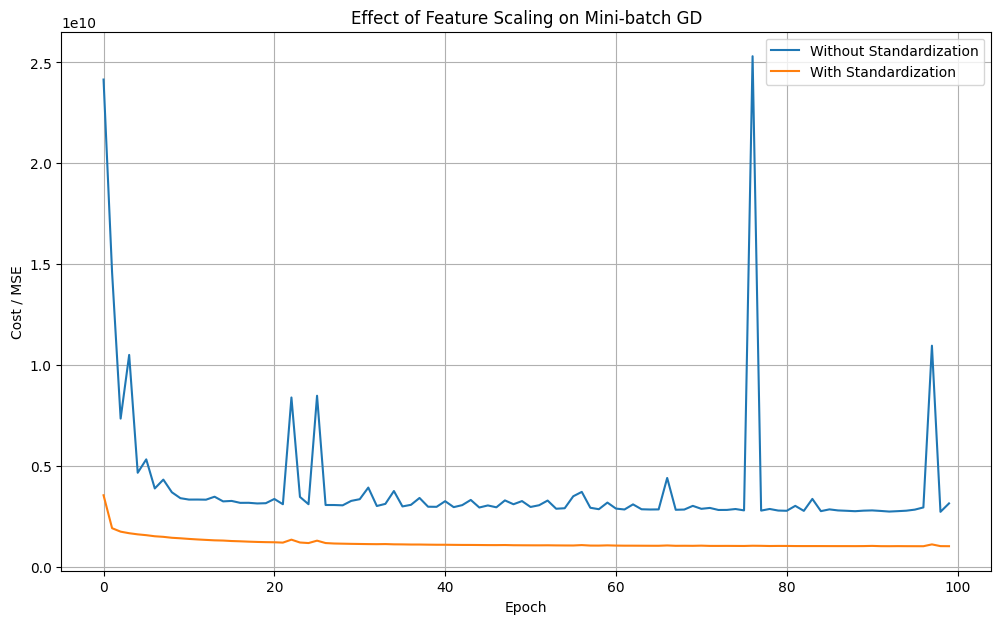

In [52]:
plt.figure(figsize=(12, 7))

plt.plot(
    unscaled_history,
    label="Without Standardization"
)

plt.plot(
    scaled_history_exp,
    label="With Standardization"
)

plt.xlabel("Epoch")
plt.ylabel("Cost / MSE")
plt.title("Effect of Feature Scaling on Mini-batch GD")
plt.legend()
plt.grid(True)
plt.show()


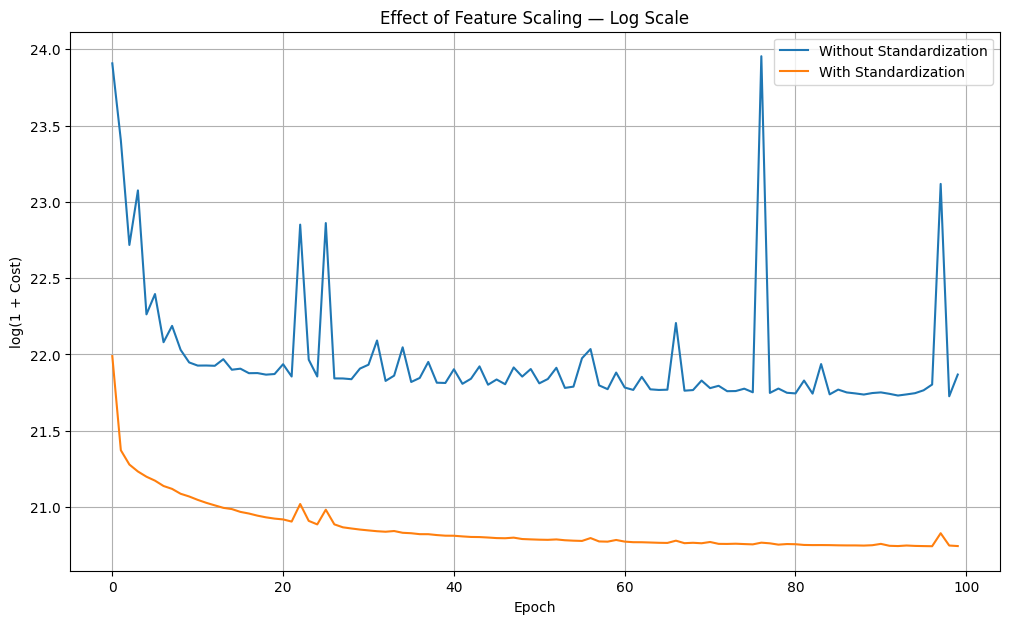

In [53]:
# Додатковий графік у логарифмічному масштабі,
# якщо абсолютні значення Cost дуже відрізняються.

plt.figure(figsize=(12, 7))

plt.plot(
    np.log1p(np.maximum(unscaled_history, 0)),
    label="Without Standardization"
)

plt.plot(
    np.log1p(np.maximum(scaled_history_exp, 0)),
    label="With Standardization"
)

plt.xlabel("Epoch")
plt.ylabel("log(1 + Cost)")
plt.title("Effect of Feature Scaling — Log Scale")
plt.legend()
plt.grid(True)
plt.show()


### Автоматичний підсумок експерименту A


In [54]:
print("EXPERIMENT A")
print("-" * 50)
print(f"Unscaled: final cost = {unscaled_history[-1]:.4f}")
print(f"Scaled:   final cost = {scaled_history_exp[-1]:.4f}")

print("\nLearning rates:")
print("Unscaled alpha = 1e-9")
print("Scaled alpha   = 0.01")

if scaled_history_exp[-1] < unscaled_history[-1]:
    print(
        "\nАвтоматичний висновок: у цьому запуску стандартизована "
        "модель завершила навчання з меншим Cost."
    )
else:
    print(
        "\nАвтоматичний висновок: у цьому запуску unscaled модель "
        "завершила навчання з меншим Cost; перевірте Learning Rate "
        "та кількість Epochs."
    )

print(
    "\nГеометричний висновок: стандартизація вирівнює масштаби "
    "ознак і робить оптимізацію Gradient Descent стабільнішою."
)


EXPERIMENT A
--------------------------------------------------
Unscaled: final cost = 3141280196.4276
Scaled:   final cost = 1020733972.3781

Learning rates:
Unscaled alpha = 1e-9
Scaled alpha   = 0.01

Автоматичний висновок: у цьому запуску стандартизована модель завершила навчання з меншим Cost.

Геометричний висновок: стандартизація вирівнює масштаби ознак і робить оптимізацію Gradient Descent стабільнішою.


# 21. Перевірка чутливості до Learning Rate

Методичка також пропонує дослідити Learning Rate. Нижче наведено
допоміжний експеримент для стандартизованих даних.

Занадто малий α → повільна збіжність.  
Занадто великий α → сильні коливання або розходження.


In [55]:
def try_learning_rate(
    method,
    X,
    y,
    learning_rate,
    epochs=30,
    batch_size=32
):
    if method == "Batch GD":
        _, history = batch_gradient_descent(
            X, y,
            learning_rate=learning_rate,
            epochs=epochs
        )
    elif method == "SGD":
        _, history = stochastic_gradient_descent(
            X, y,
            learning_rate=learning_rate,
            epochs=epochs
        )
    elif method == "Mini-batch GD":
        _, history = mini_batch_gradient_descent(
            X, y,
            learning_rate=learning_rate,
            epochs=epochs,
            batch_size=batch_size
        )
    else:
        raise ValueError("Unknown method")

    history = np.asarray(history, dtype=float)
    stable = np.all(np.isfinite(history))

    if stable and len(history) >= 2:
        # Перевіряємо наявність явного росту після початку оптимізації.
        exploding = history[-1] > history[0] * 100
    else:
        exploding = True

    return history, stable and not exploding


In [56]:
learning_rates = {
    "Batch GD": [0.001, 0.01, 0.05],
    "SGD": [0.00001, 0.0001, 0.001],
    "Mini-batch GD": [0.001, 0.01, 0.05]
}

lr_results = []

for method, rates in learning_rates.items():
    for lr in rates:
        history, stable = try_learning_rate(
            method,
            X_train_processed,
            y_train_np,
            lr,
            epochs=30,
            batch_size=32
        )

        lr_results.append({
            "Method": method,
            "Learning Rate": lr,
            "Final Cost": history[-1],
            "Stable": stable
        })

lr_results_df = pd.DataFrame(lr_results)
display(lr_results_df)


,Method,Learning Rate,Final Cost,Stable
0,Batch GD,0.00100,2.880959e+10,True
1,Batch GD,0.01000,3.401868e+09,True
2,Batch GD,0.05000,1.589103e+09,True
3,SGD,0.00001,4.296662e+09,True
4,SGD,0.00010,1.429684e+09,True
5,SGD,0.00100,1.020963e+09,True
6,Mini-batch GD,0.00100,1.749103e+09,True
7,Mini-batch GD,0.01000,1.137286e+09,True
8,Mini-batch GD,0.05000,1.013019e+09,True


# 22. Фінальна таблиця результатів


In [57]:
final_results = results_df.copy()

final_results["Train R2"] = final_results["Train R2"].round(4)
final_results["Validation R2"] = final_results["Validation R2"].round(4)
final_results["Test R2"] = final_results["Test R2"].round(4)

display(final_results)


,Method,Train R2,Validation R2,Test R2
0,Batch GD,0.8137,0.8230,0.8268
1,SGD,0.8102,0.8203,0.8241
2,Mini-batch GD,0.8286,0.8325,0.8384


In [58]:
print("=" * 70)
print("FINAL AUTOMATIC SUMMARY")
print("=" * 70)

best_row = results_df.loc[results_df["Test R2"].idxmax()]

print(f"Best method by Test R²: {best_row['Method']}")
print(f"Train R²:       {best_row['Train R2']:.4f}")
print(f"Validation R²:  {best_row['Validation R2']:.4f}")
print(f"Test R²:        {best_row['Test R2']:.4f}")
print(f"Train-Test gap: {best_row['Train R2'] - best_row['Test R2']:.4f}")

print("\nNormality:")
print(f"Shapiro-Wilk p-value: {shapiro_p:.6g}")

print("\nMulticollinearity:")
print(
    f"Maximum VIF: {max_vif_row['Feature']} = "
    f"{max_vif_row['VIF']:.3f}"
)

print("\nScaling experiment:")
print(f"Unscaled final cost: {unscaled_history[-1]:.4f}")
print(f"Scaled final cost:   {scaled_history_exp[-1]:.4f}")


FINAL AUTOMATIC SUMMARY
Best method by Test R²: Mini-batch GD
Train R²:       0.8286
Validation R²:  0.8325
Test R²:        0.8384
Train-Test gap: -0.0097

Normality:
Shapiro-Wilk p-value: 9.79774e-19

Multicollinearity:
Maximum VIF: OverallQual = 2.400

Scaling experiment:
Unscaled final cost: 3141280196.4276
Scaled final cost:   1020733972.3781


# 23. Відповіді на теоретичні питання

## Чому потрібно робити split до scaling / encoding?

Тому що preprocessing може отримувати статистичну інформацію з даних.
Якщо спочатку навчити preprocessing на всьому датасеті, Validation та
Test вплинуть на параметри перетворення. Це є Data Leakage.

## Що робити з новою категорією на Validation/Test?

Не можна перевчати encoder на Validation/Test. Використовується encoder,
навчений на Train. У цій роботі застосовано `handle_unknown="ignore"`.

## Який метод GD стабільніший?

Batch GD використовує весь Train для оцінки градієнта, тому зазвичай
має найменший шум. SGD має найбільше коливань. Mini-batch є компромісом.

## Як batch size впливає на навчання?

Менший batch дає більш шумний градієнт і більше оновлень, але може
коливатися сильніше. Більший batch дає стабільнішу оцінку градієнта,
але одне оновлення потребує більше обчислень.

## Як Learning Rate впливає на збіжність?

Малий Learning Rate робить навчання повільним. Великий Learning Rate
може спричинити коливання навколо мінімуму або повне розходження.

## Чи може R² бути від'ємним?

Так. Це означає, що модель дає більшу суму квадратів помилок, ніж
простий прогноз середнім значенням цільової змінної.

## Що означає велика різниця між Train та Test R²?

Вона може свідчити про overfitting: модель добре підлаштувалася
під Train, але гірше узагальнює на невідомі дані.

## Чому мультиколінеарність проблемна?

Сильний зв'язок між ознаками робить оцінки окремих коефіцієнтів
нестабільними та ускладнює їхню інтерпретацію.

## Чому scaling важливий для Gradient Descent?

Коли ознаки мають дуже різні масштаби, поверхня функції втрат може
мати витягнуту геометрію. Gradient Descent тоді може повільно
збігатися або вимагати дуже малого Learning Rate. Стандартизація
вирівнює масштаби і полегшує оптимізацію.


# 24. Загальний висновок

У лабораторній роботі було досліджено Ames Housing Dataset та побудовано
модель лінійної регресії для прогнозування `SalePrice`.

На етапі EDA було проаналізовано структуру датасету, пропущені значення,
статистичні характеристики, розподіл цільової змінної та кореляції.

Дані були розділені на Train, Validation та Test **до preprocessing**.
Параметри заповнення пропусків, One-Hot Encoding та StandardScaler
отримувалися тільки з Train, що дозволяє уникнути Data Leakage.

Лінійну регресію було реалізовано самостійно засобами NumPy у вигляді
`ŷ = Xw + b`. MSE та градієнти обчислюються векторизовано.

Було реалізовано три алгоритми Gradient Descent:
Batch GD, SGD та Mini-batch GD. Їхню поведінку порівняно за графіком
Cost Function.

Якість моделей оцінено за R² на Train, Validation та Test. Найкращий
метод визначається автоматично за Test R² у фінальній таблиці.

Також перевірено статистичні припущення лінійної регресії:
лінійність, нормальність залишків, гомоскедастичність та
мультиколінеарність.

В експерименті A досліджено вплив стандартизації на Mini-batch Gradient
Descent. Результати дозволяють побачити, як масштаб ознак впливає на
вибір Learning Rate та швидкість/стабільність збіжності.

> **Перед здачею:** перегляньте всі графіки та замініть місця
> `[вказати фактичний патерн]` у Markdown-висновках конкретними
> спостереженнями з отриманих графіків.


# 25. Checklist перед завантаженням на GitHub

- [ ] `train.csv` доступний у `data/train.csv`
- [ ] Notebook запускається без помилок
- [ ] EDA виконано
- [ ] Пропуски досліджено
- [ ] Кореляції показано
- [ ] Вибір ознак обґрунтовано
- [ ] Train / Validation / Test виконано до preprocessing
- [ ] Data Leakage пояснено
- [ ] One-Hot Encoding виконано тільки через Train `fit`
- [ ] StandardScaler `fit` виконано тільки на Train
- [ ] Linear Regression реалізовано самостійно через NumPy
- [ ] MSE реалізовано
- [ ] Градієнти реалізовано
- [ ] Batch GD реалізовано
- [ ] SGD реалізовано
- [ ] Mini-batch GD реалізовано
- [ ] Графік трьох методів побудовано
- [ ] R² для Train / Validation / Test отримано
- [ ] Residuals vs Fitted побудовано
- [ ] Q-Q plot побудовано
- [ ] Shapiro-Wilk виконано
- [ ] Scale-Location побудовано
- [ ] Correlation Matrix для multicollinearity показано
- [ ] VIF розраховано
- [ ] Вплив multicollinearity пояснено
- [ ] Experiment A виконано
- [ ] Автоматичні результати збережені в Notebook
- [ ] Висновки написані на основі фактичних графіків та чисел
